In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib

In [12]:
# some values used for calculations

k = 8.61733e-5; # boltzmann constant in eV/K
TK = 1000+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 200+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,50); # oxygen partial pressure range

In [13]:
# Equilibrium defect reaction constants

KR = 1.06E71*np.exp(-5.69/(k*TK)) #undoped BaTiO3 
# KRQ = 1.06E71*np.exp(-5.69/(k*TQK))
Ki = 8.55E44*np.exp(-2.91/(k*TK))
# KiQ = 8.55E44*np.exp(-2.91/(k*TQK))
# Ki = 1.15E47*np.exp(-2.92/(k*TK))
KiQ = 1.15E47*np.exp(-2.92/(k*TQK))
# KR = 1E72*np.exp(-6.00/(k*TK))
KRQ = 1E72*np.exp(-6.00/(k*TQK))

KS = (3.4E105)*np.exp(-2.795/(k*TK)) #acceptor and nominally undoped BaTiO3

KPSB = (1.15E22)**2*np.exp(10.15)*np.exp(-2.32/(k*TK))
KPST = (1.15E22)**3*np.exp(8.06)*np.exp(-2.89/(k*TK))
KFS = (1.15E22)**5*np.exp(10)*np.exp(-3.33/(k*TK))

# KMn1 = 3.2E22*np.exp(-1.72/(k*TK))
# KMn1Q = 3.2E22*np.exp(-1.72/(k*TQK))
# KMn2 = 0.8E22*np.exp(-1.12/(k*TK))
# KMn2Q = 0.8E22*np.exp(-1.12/(k*TQK))
KMn1 = 1.4E22*np.exp(-1.72/(k*TK))
KMn1Q = 1.4E22*np.exp(-1.72/(k*TQK))
KMn2 = 1.4E22*np.exp(-1.13/(k*TK))
KMn2Q = 1.4E22*np.exp(-1.13/(k*TQK))

In [14]:
# empty lists for each defect concentration; will be filled later

CVO2 = np.zeros(len(a))
CVO2q = np.zeros(len(a))
CVO2Mn = np.zeros(len(a))
CVO2Mnq = np.zeros(len(a))
CVO2Mg = np.zeros(len(a))
CVO2Mgq = np.zeros(len(a))
CVO2MnY = np.zeros(len(a))
CVO2MnYq = np.zeros(len(a))

CVTi4 = np.zeros(len(a))
CVTi4q = np.zeros(len(a))
CVTi4Mn = np.zeros(len(a))
CVTi4Mnq = np.zeros(len(a))
CVTi4Mg = np.zeros(len(a))
CVTi4Mgq = np.zeros(len(a))
CVTi4MnY = np.zeros(len(a))
CVTi4MnYq = np.zeros(len(a))

CVBa2 = np.zeros(len(a))
CVBa2q = np.zeros(len(a))
CVBa2Mn = np.zeros(len(a))
CVBa2Mnq = np.zeros(len(a))
CVBa2Mg = np.zeros(len(a))
CVBa2Mgq = np.zeros(len(a))
CVBa2MnY = np.zeros(len(a))
CVBa2MnYq = np.zeros(len(a))

CMn0 = np.zeros(len(a))
CMn1 = np.zeros(len(a))
CMn2 = np.zeros(len(a))
CMn0q = np.zeros(len(a))
CMn1q = np.zeros(len(a))
CMn2q = np.zeros(len(a))
CMn0MnY = np.zeros(len(a))
CMn1MnY = np.zeros(len(a))
CMn2MnY = np.zeros(len(a))
CMn0MnYq = np.zeros(len(a))
CMn1MnYq = np.zeros(len(a))
CMn2MnYq = np.zeros(len(a))


n = np.zeros(len(a))
nq = np.zeros(len(a))
nMn = np.zeros(len(a))
nMnq = np.zeros(len(a))
nMg = np.zeros(len(a))
nMgq = np.zeros(len(a))
nMnY = np.zeros(len(a))
nMnYq = np.zeros(len(a))

p = np.zeros(len(a))
pq = np.zeros(len(a))
pMn = np.zeros(len(a))
pMnq = np.zeros(len(a))
pMg = np.zeros(len(a))
pMgq = np.zeros(len(a))
pMnY = np.zeros(len(a))
pMnYq = np.zeros(len(a))


In [17]:
"""
[1] A/B = 1 & High T & Undoped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E40, maxiter=200)
    
    n[i] = np.array(sol1).astype(np.float64)
    p[i] = Ki/n[i]
    CVO2[i] = KR/((n[i]**2)*(y**(1/2)))
    CVTi4[i] = (KS/(KR**3))**(1/2)*(n[i]**3)*(y**(3/4))
    CVBa2[i] = CVTi4[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Undoped; T = {TC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

RuntimeError: Failed to converge after 200 iterations.

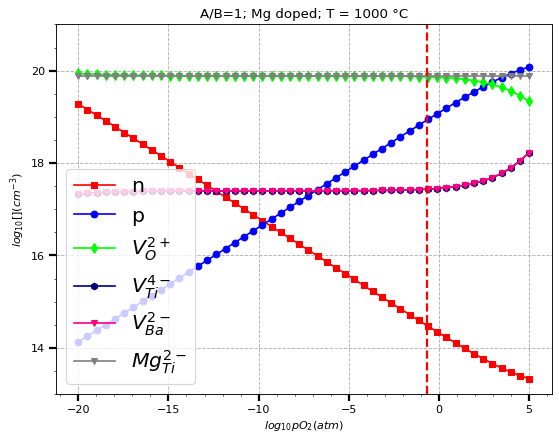

In [16]:
"""
[2] A/B = 1 & High T & Mg doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + 2[MgTi2-]
    where 
    [VBa2-] = [VTi4-] with full Schottky reaction
    all Mg was assumed to be ionzied. Thus, their concentration is not a function of oxygen partial pressure
"""

CMgt = 7.7E19 # total Mg concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CMg = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + 2*CMgt - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    nMg[i] = np.array(sol1).astype(np.float64)
    pMg[i] = Ki/nMg[i]
    CVO2Mg[i] = KR/((nMg[i]**2)*(y**(1/2)))
    CVTi4Mg[i] = (KS/(KR**3))**(1/2)*(nMg[i]**3)*(y**(3/4))
    CVBa2Mg[i] = CVTi4Mg[i]
    CMg[i] = CMgt

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mg doped; T = {TC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMg), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMg),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mg),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4Mg),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2Mg),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMg),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mg_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

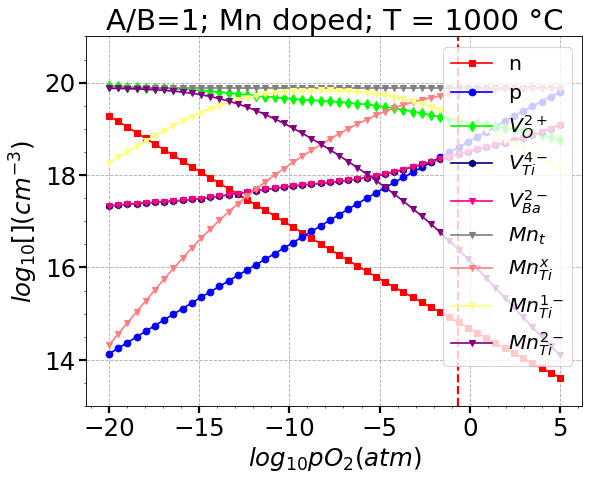

In [18]:
"""
[3] A/B = 1 & High T & Mn doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]
KMn1 = 3.2E22*np.exp(-1.72/(k*TK)): first ionization of Mn; Mn_{Ti}^{1-} = Mn_{Ti}^{x} + e^{1-} [ref]
KMn2 = 0.8E22*np.exp(-1.12/(k*TK)): second ionization of Mn; Mn_{Ti}^{2-} = Mn_{Ti}^{1-} + e^{1-} [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""

CMn = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    nMn[i] = np.array(sol1).astype(np.float64)
    pMn[i] = Ki/nMn[i]
    CVO2Mn[i] = KR/((nMn[i]**2)*(y**(1/2)))
    CVTi4Mn[i] = (KS/(KR**3))**(1/2)*(nMn[i]**3)*(y**(3/4))
    CVBa2Mn[i] = CVTi4Mn[i]
    CMn1[i] = CMn/(KMn1/nMn[i] + 1 + nMn[i]/KMn2)
    CMn2[i] = CMn1[i]*nMn[i]/KMn2
    CMn0[i] = CMn - CMn1[i] - CMn2[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mn doped; T = {TC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMn), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMn),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mn),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4Mn),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2Mn),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1+CMn2+CMn0),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1),marker='v', c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2),marker='v', c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc='best',fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

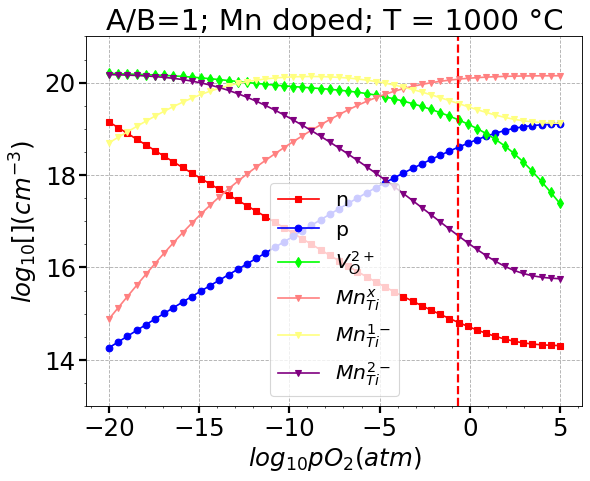

In [19]:
"""
[3] A/B = 1 & High T & Mn doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]

KMn1 = 3.2E22*np.exp(-1.72/(k*TK)): first ionization of Mn; Mn_{Ti}^{1-} = Mn_{Ti}^{x} + e^{1-} [ref]
KMn2 = 0.8E22*np.exp(-1.12/(k*TK)): second ionization of Mn; Mn_{Ti}^{2-} = Mn_{Ti}^{1-} + e^{1-} [ref]

Charge neutrality condition: p + 2[VO2+] = n + [MnTi1-] + 2[MnTi2-]
"""

CMn = 2*7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30,maxiter=200)
    
    nMn[i] = np.array(sol1).astype(np.float64)
    pMn[i] = Ki/nMn[i]
    CVO2Mn[i] = KR/((nMn[i]**2)*(y**(1/2)))
    CMn1[i] = CMn/(KMn1/nMn[i] + 1 + nMn[i]/KMn2)
    CMn2[i] = CMn1[i]*nMn[i]/KMn2
    CMn0[i] = CMn - CMn1[i] - CMn2[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mn doped; T = {TC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMn), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMn),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mn),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
# ax1.plot(np.log10(a),np.log10(CMn1+CMn2+CMn0),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1),marker='v', c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2),marker='v', c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc='best',fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

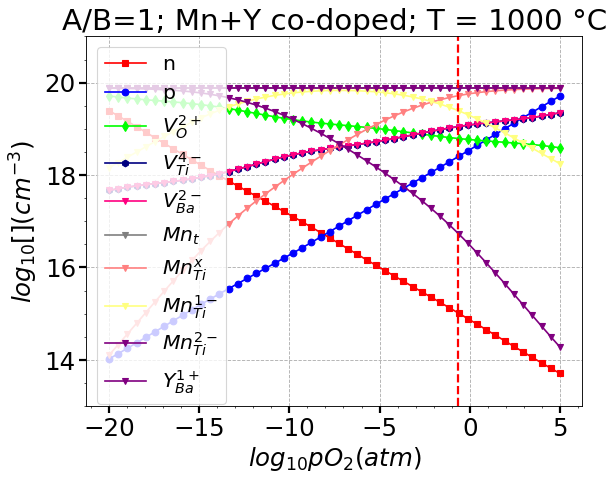

In [20]:
"""
[4] A/B = 1 & High T & Mn+Y co-doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]
KMn1 = 3.2E22*np.exp(-1.72/(k*TK)): first ionization of Mn; Mn_{Ti}^{1-} = Mn_{Ti}^{x} + e^{1-} [ref]
KMn2 = 0.8E22*np.exp(-1.12/(k*TK)): second ionization of Mn; Mn_{Ti}^{2-} = Mn_{Ti}^{1-} + e^{1-} [ref]

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where 
    [VBa2-] = [VTi4-] with full Schottky reaction
    all Y was assumed to be ionzied and located on A(Ba)-site. Thus, their concentration is not a function of oxygen partial pressure
"""

CMn = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    nMnY[i] = np.array(sol1).astype(np.float64)
    pMnY[i] = Ki/nMnY[i]
    CVO2MnY[i] = KR/((nMnY[i]**2)*(y**(1/2)))
    CVTi4MnY[i] = (KS/(KR**3))**(1/2)*(nMnY[i]**3)*(y**(3/4))
    CVBa2MnY[i] = CVTi4MnY[i]
    CMn1MnY[i] = CMn/(KMn1/nMnY[i] + 1 + nMnY[i]/KMn2)
    CMn2MnY[i] = CMn1MnY[i]*nMnY[i]/KMn2
    CMn0MnY[i] = CMn - CMn1MnY[i] - CMn2MnY[i]
    CY[i] = CYt

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mn+Y co-doped; T = {TC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMnY), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMnY),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2MnY),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4MnY),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2MnY),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1MnY+CMn2MnY+CMn0MnY),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0MnY),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1MnY),marker='v', c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2MnY),marker='v', c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY),marker='v', c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc='best',fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

In [21]:
"""
[5] A/B = 1 & Low T & Undoped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
"""
# First, calculate each defect concentration at T=1150 oC & pO2=0.21 atm

y = 0.21 # y: oxygen partial pressure in atm

def f(x): # x: electron concentration
    return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
sol1 = brentq(f,1E10,1E30,maxiter=200)

n_0 = np.array(sol1).astype(np.float64)
p_0 = Ki/n_0
CVO2_0 = KR/((n_0**2)*(y**(1/2)))
CVTi4_0 = (KS/(KR**3))**(1/2)*(n_0**3)*(y**(3/4))
CVBa2_0 = CVTi4_0
"""
# Calculate each defect concentration as a function of oxygen partial pressure at low T=500 oC with frozen-in ionic defect concentations
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: oxygen vacancy concentration
        return (x + 6*CVBa2_0 - (KiQ/x) - 2*(KRQ/((x**2)*(y**(1/2)))))

    sol1 = brentq(f,1,1E40,maxiter=200)
    
    nq[i] = np.array(sol1).astype(np.float64)
    pq[i] = KiQ/nq[i]
    CVO2q[i] = KRQ/((nq[i]**2)*(y**(1/2)))
    CVTi4q[i] = CVTi4_0
    CVBa2q[i] = CVBa2_0

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Undoped; T = {TQC} \u00B0C')
matplotlib.rcParams.update({'font.size': 22})
ax1.set_ylim(ymin=13, ymax=21)
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nq), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pq),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2q),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4q),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2q),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

ValueError: f(a) and f(b) must have different signs

/tmp/ipykernel_1839/95660255.py:56: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CVBa2Mgq),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')


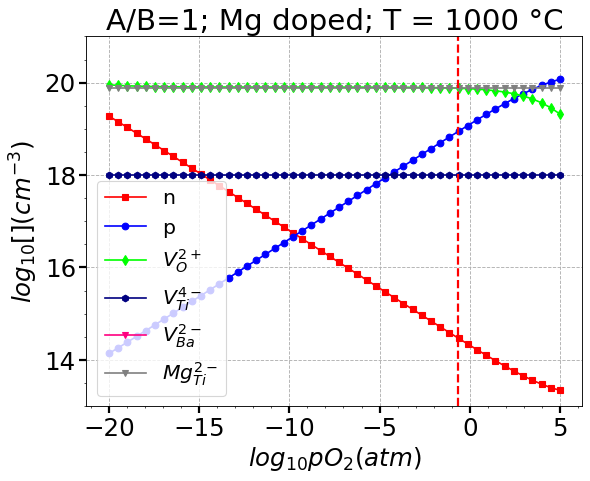

In [15]:
"""
[6] A/B = 1 & Low T & Mg doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + 2[MgTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""

# First, calculate each defect concentration at T=1150 oC & pO2=0.21 atm

CMgt = 7.7E19 # total Mg concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

y = 0.21 # y: oxygen partial pressure in atm

def f(x): # x: electron concentration
    return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + 2*CMgt - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
sol1 = brentq(f,1E10,1E30,maxiter=200)

n_0Mg = np.array(sol1).astype(np.float64)
p_0Mg = Ki/n_0Mg
CVO2_0Mg = KR/((n_0Mg**2)*(y**(1/2)))
CVTi4_0Mg = (KS/(KR**3))**(1/2)*(n_0Mg**3)*(y**(3/4))
CVBa2_0Mg = CVTi4_0Mg

# Calculate each defect concentration as a function of oxygen partial pressure
CMgq = np.zeros(len(a))

for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*CVBa2_0Mg + 2*CMgt - (KiQ/x) - 2*(KRQ/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30,maxiter=200)
    
    nMgq[i] = np.array(sol1).astype(np.float64)
    pMgq[i] = KiQ/nMgq[i]
    CVO2Mgq[i] = KRQ/((nMgq[i]**2)*(y**(1/2)))
    CVTi4Mgq[i] = CVBa2_0Mg
    CVBa2Mg[i] = CVTi4Mgq[i]
    CMgq[i] = CMgt

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mg doped; T = {TQC} \u00B0C')
ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMgq), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMgq),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mgq),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4Mgq),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2Mgq),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMgq),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mg_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

/tmp/ipykernel_1440/1193938062.py:56: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CVTi4Mnq),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
/tmp/ipykernel_1440/1193938062.py:57: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CVBa2Mnq),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
/tmp/ipykernel_1440/1193938062.py:59: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0q),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
/tmp/ipykernel_1440/1193938062.py:59: RuntimeWarning: invalid value encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0q),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


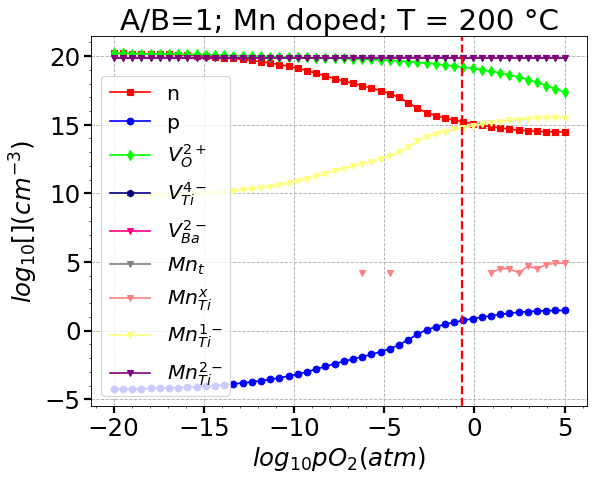

In [23]:
"""
[7] A/B = 1 & Low T & Mn doped

KR = 1.06E71*np.exp(-5.69/(k*TK)): reduction reaction [ref]
Ki = 8.55E44*np.exp(-2.91/(k*TK)): Intrinsic electron-hole generation [ref]
KS = (3.4E105)*np.exp(-2.795/(k*TK)): full Schottky reaction [ref]
KMn1 = 3.2E22*np.exp(-1.72/(k*TK)): first ionization of Mn; Mn_{Ti}^{1-} = Mn_{Ti}^{x} + e^{1-} [ref]
KMn2 = 0.8E22*np.exp(-1.12/(k*TK)): second ionization of Mn; Mn_{Ti}^{2-} = Mn_{Ti}^{1-} + e^{1-} [ref]

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
# First, calculate each defect concentration at T=1150 oC & pO2=0.21 atm

CMn = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
"""
y = 0.21 # y: oxygen partial pressure in atm

def f(x): # x: electron concentration
    return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
sol1 = brentq(f,1,1E30,maxiter=200)

n_0Mn = np.array(sol1).astype(np.float64)
p_0Mn = Ki/n_0Mn
CVO2_0Mn = KR/((n_0Mn**2)*(y**(1/2)))
CVTi4_0Mn = (KS/(KR**3))**(1/2)*(n_0Mn**3)*(y**(3/4))
CVBa2_0Mn = CVTi4_0Mn
"""
# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*CVO2Mn[i])
    sol1 = brentq(f,1,1E30,maxiter=200)
    
    nMnq[i] = np.array(sol1).astype(np.float64)
    pMnq[i] = KiQ/nMnq[i]
    CVO2Mnq[i] = CVO2Mn[i]
    # CVTi4Mnq[i] = CVTi4_0Mn
    # CVBa2Mnq[i] = CVTi4Mnq[i]
    CMn1q[i] = CMn/(KMn1Q/nMnq[i] + 1 + nMnq[i]/KMn2Q)
    CMn2q[i] = CMn1q[i]*nMnq[i]/KMn2Q
    CMn0q[i] = CMn - CMn1q[i] - CMn2q[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Mn doped; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMnq), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMnq),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mnq),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4Mnq),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2Mnq),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1q+CMn2q+CMn0q),marker='v', c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0q),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1q),marker='v', c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2q),marker='v', c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

In [31]:
for i in range(len(a)): # This part is for obtaining a full equilibirum defect structure at TK(TC) with partial Schottky reaction (Ti-rich)
    y = a[i] # oxygen partial pressure in atm
    AtoB = 0.999
    CVBa2_Tirich = 1.15E22*(1-AtoB)
    
    def f(x): # x = electron concentration
        return (x + 2*CVBa2_Tirich - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E25,maxiter=200)
    
    n[i] = np.array(sol1).astype(np.float64) # a concentration of electron
    p[i] = Ki/n[i] # concentration of hole
    CVO2[i] = KR/((n[i]**2)*(y**(1/2))); # a concentration of oxygen vacancies (Reduction reaction)
    CVBa2[i] = CVBa2_Tirich
    # CVTi4[i] = AtoB*CVBa2[i]

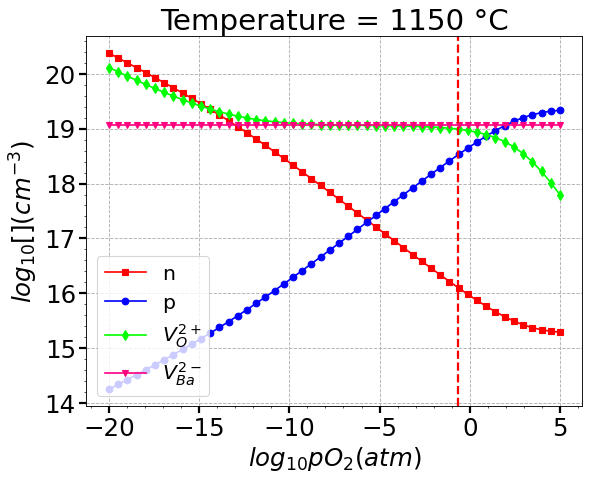

In [42]:
fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Temperature = {TC} \u00B0C')
# ax1.set_ylim(ymin=10, ymax=22)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(axis='both',length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
# ax1.plot(np.log10(a),np.log10(CVTi4),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
# Add grid lines
ax1.grid(True, which='major', linestyle='--')
# ax1.grid(True, which='minor', linestyle=':')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)

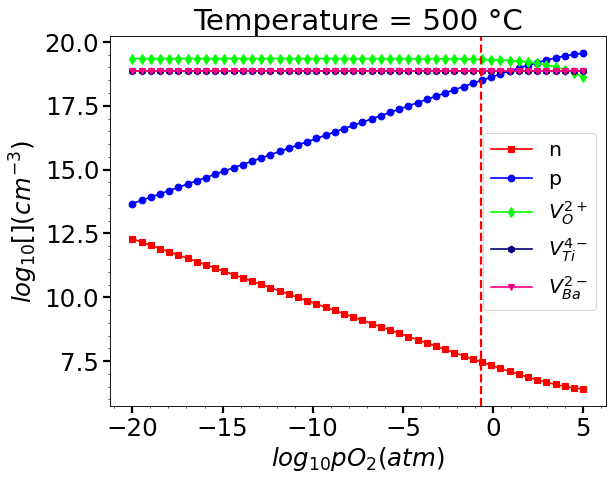

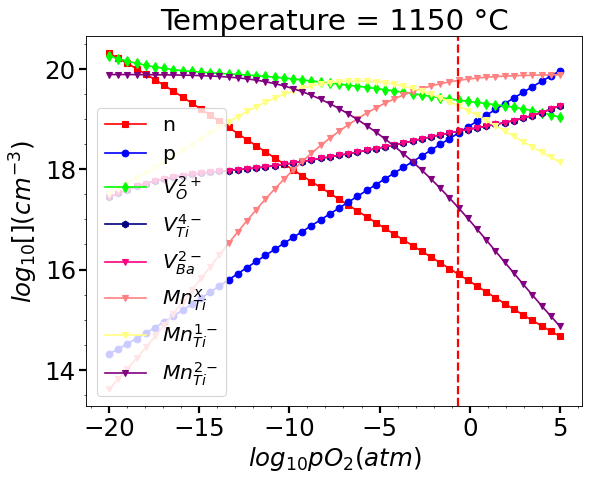

In [24]:
y = 0.21 # oxygen partial pressure in atm
    
def f(x): # x = electron concentration
    return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMn/(KMn1/x + 1 + x/KMn2))*(1 + 2*x/KMn2) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2))))) # only Full Schottky reaction; [VBa] = [VTi]
sol1 = brentq(f,1E10,1E30,maxiter=200)

nMn_0 = np.array(sol1).astype(np.float64) # a concentration of electron
pMn_0 = Ki/nMn_0
CVO2Mn_0 = KR/((nMn_0**2)*(y**(1/2))); # a concentration of oxygen vacancies (Reduction reaction)
CVTi4Mn_0 = (KS/(KR**3))**(1/2)*(nMn_0**3)*(y**(3/4)) # a concentration of cation vacancies (Schottky reaction)
CVBa2Mn_0 = CVTi4Mn_0
CMn1_0 = CMn/(KMn1/nMn_0 + 1 + nMn_0/KMn2)
CMn2_0 = CMn1_0*nMn_0/KMn2
CMn0_0 = CMn - CMn1_0 - CMn2_0

In [26]:
for i in range(len(a)): # This part is for obtaining a full equilibirum defect structure at TK(TC)
    y = a[i] # oxygen partial pressure in log scale atm
    
    def f(x): # x = electron concentration
        return (x + 6*CVBa2Mn_0 + CMn1_0 + 2*CMn2_0 - (KiQ/x) - 2*(KRQ/((x**2)*(y**(1/2))))) # only Full Schottky reaction; [VBa] = [VTi]
    sol1 = brentq(f,1,1E30,maxiter=200)
    
    nMnq[i] = np.array(sol1).astype(np.float64) # a concentration of electron
    pMnq[i] = KiQ/nMnq[i]
    CVO2Mnq[i] = KRQ/((nMnq[i]**2)*(y**(1/2))); # a concentration of oxygen vacancies (Reduction reaction)
    CVTi4Mnq[i] = CVTi4Mn_0
    CVBa2Mnq[i] = CVBa2Mn_0
    CMn1q[i] = CMn1_0
    CMn2q[i] = CMn2_0
    CMn0q[i] = CMn - CMn1q[i] - CMn2q[i]

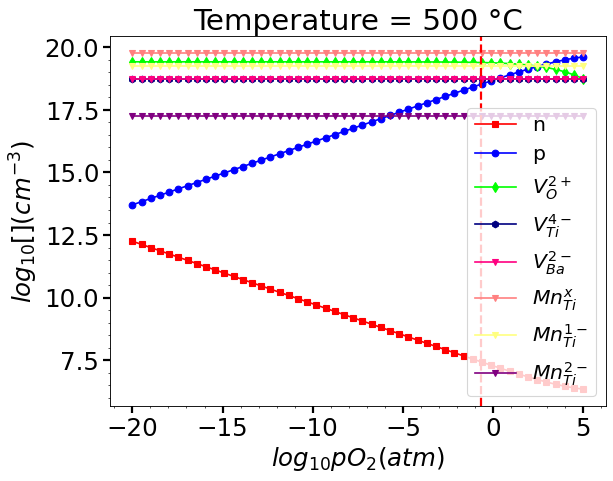

In [28]:
fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Temperature = {TQC} \u00B0C')
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nMnq), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pMnq),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2Mnq),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVTi4Mnq),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CVBa2Mnq),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
# ax1.plot(np.log10(a),np.log10(CMn),marker='v', c =[255/255, 0/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0q),marker='v', c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1q),marker='v', c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2q),marker='v', c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc='best',fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)